In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

import sys
import pickle

sys.path.append('..')
sys.path.append('../..')

from src.Environment.environment_v3 import MyModelSelectionEnv
from src.utils import train_test_anomaly
from src.Components.data_processing import data_process
from sklearn.model_selection import train_test_split

2024-04-19 10:26:39.679483: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-19 10:26:39.679575: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-19 10:26:39.717238: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-19 10:26:39.799507: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-19 10:26:41.134634: W tensorflow/compiler/tf2

In [2]:
import tf_agents.bandits.agents as bandit_agents
from tf_agents.metrics import tf_metrics
from tf_agents.trajectories import time_step as ts
from tf_agents.drivers import dynamic_step_driver
from tf_agents.environments import tf_py_environment
from tf_agents.networks import q_network
from tf_agents.bandits.replay_buffers import bandit_replay_buffer
from tf_agents.metrics import export_utils
from tf_agents.policies import policy_saver

### Importing Data and Setting Up the Environment

In [3]:
file_path = '../datasets/Dodgers/101-freeway-traffic.test.out'

columns = ['value', 'anomaly']

df = pd.read_csv(file_path, names=columns, header=None)

In [4]:
# _, test_data = train_test_anomaly(df)

train_data, test_data = train_test_split(df, test_size=0.3, shuffle=False)

list_threshold = [0.00755, 1.0, 2.88065, 1.5832]

list_gtruth_test = test_data[['anomaly']].values.reshape(-1, 1)

train_data = train_data[train_data['value'] >= 0]
list_gtruth_train = train_data[['anomaly']].values.reshape(-1, 1)

### Preparing the Parameters

In [20]:
def load_models():
       
    model1 = pickle.load(open(f'../saved_models/iforest_dodgers_v3.sav','rb'))
    model2 = pickle.load(open(f'../saved_models/lof_dodgers_v2.sav', 'rb'))
    model3 =  pickle.load(open(f'../saved_models/clof_dodgers_v2.sav', 'rb')) 
    model4 = pickle.load(open(f'../saved_models/copod_dodgers_v2.sav', 'rb'))

    return [model1, model2, model3, model4]

In [21]:
model = load_models()

train_vals = train_data[['value']].to_numpy()

score_list = []

mod_scores1 = model[0].decision_function(train_vals)
mod_pred1 = [1 if (score < list_threshold[0]) else 0 for score in mod_scores1]

mod_pred2 = model[1].predict(train_vals)
mod_pred3 = model[2].predict(train_vals)
mod_score4 = model[3].decision_function(train_vals)

mod_pred4 = [1 if (score > list_threshold[3]) else 0 for score in mod_score4]

score_list_train = [mod_pred1, mod_pred2, mod_pred3, mod_pred4]

In [7]:
train_env = MyModelSelectionEnv(train_data, list_thresholds=list_threshold, list_gtruth=list_gtruth_train, list_predicted_score=score_list_train)
train_environment = tf_py_environment.TFPyEnvironment(train_env) # Converts the PyEnvironment to TFEnvironment

### Setting Up the Neural Epsilon Greedy Agent

In [8]:
action_spec = train_environment.action_spec()
observation_spec = train_environment.time_step_spec().observation

EPSILON = 0.1
LAYERS = (50, 50, 50)
LR = 0.005

TRAINING_LOOPS = 500
steps_per_loop = 1
async_steps_per_loop = 1

network = q_network.QNetwork(
          input_tensor_spec=observation_spec,
          action_spec=action_spec,
          fc_layer_params=LAYERS,
      )

In [9]:

eps_agent = bandit_agents.neural_epsilon_greedy_agent.NeuralEpsilonGreedyAgent(action_spec=train_environment.action_spec(), time_step_spec=train_environment.time_step_spec(), reward_network=network, optimizer=tf.compat.v1.train.AdamOptimizer(learning_rate=LR),
        epsilon=EPSILON,
        emit_policy_info='predicted_rewards_mean',
        info_fields_to_inherit_from_greedy=['predicted_rewards_mean'])

eps_agent.initialize()

### Replay Buffers and Drivers

In [10]:
data_spec = eps_agent.policy.trajectory_spec

In [11]:
def get_replay_buffer(
    data_spec, batch_size, steps_per_loop, async_steps_per_loop
):
  """Return a `TFUniformReplayBuffer` for the given `agent`."""
  return bandit_replay_buffer.BanditReplayBuffer(
      data_spec=data_spec,
      batch_size=batch_size,
      max_length=steps_per_loop * async_steps_per_loop,
  )

In [12]:
replay_buffer = get_replay_buffer(
      data_spec, train_environment.batch_size, steps_per_loop, async_steps_per_loop
  )

In [13]:
# Observers

step_metric = tf_metrics.EnvironmentSteps()
metrics = [
      tf_metrics.NumberOfEpisodes(), # Counts the number of episodes in the environment
      tf_metrics.AverageEpisodeLengthMetric(batch_size=1),   # Metric to compute the average episode length
      tf_metrics.AverageReturnMetric(batch_size=1) # Metric to compute the average return
  ]

add_batch_fn = replay_buffer.add_batch # Adds a batch of items on the replay buffer

observers = [add_batch_fn, step_metric] + metrics # List of observers for the driver

In [14]:
driver = dynamic_step_driver.DynamicStepDriver(
      env=train_environment,
      policy=eps_agent.collect_policy,
      num_steps=steps_per_loop * train_environment.batch_size,
      observers=observers,
  )

In [15]:
# Replay Buffer Values

"""
    The .as_dataset method creates and returns a dataset as entries from the buffer.

    A single entry from the dataset is the result of the following pipeline:

    - Sample sequences from the underlying data store
    - (Optional) Process them with 'sequence_preprocess_fn'
    - (Optional) Split them into subsequences of length num_steps
    - (Optional) Batch them into batches of size 'sample_batch_size'

    In practice, this pipeline is executed in parallel as much as possible if num_parallel_calls != 1.

    
"""

dataset_it = iter(
        replay_buffer.as_dataset(
            sample_batch_size=1,
            num_steps=1,
            single_deterministic_pass=True,
        )
    )

In [16]:
def training_loop(train_step, metrics):
 
    driver.run()
     
    batch_size = driver.env.batch_size
    dataset_it = iter(
        replay_buffer.as_dataset(
            sample_batch_size=batch_size,
            num_steps=1,
            single_deterministic_pass=True,
        )
    )

    meter = driver.observers[1:]
    for batch_id in range(async_steps_per_loop):
      experience, unused_buffer_info = dataset_it.get_next()
      loss_info = eps_agent.train(experience)
      print(loss_info)

      export_utils.export_metrics(
          step=train_step * async_steps_per_loop + batch_id,
          metrics=meter,
          loss_info=loss_info,
      )

    replay_buffer.clear()


In [17]:
for i in range(1, 5000):

    training_loop(train_step=i, metrics=metrics)

Step: 1, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=193485.38>, extra=())
Step: 2, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=5713728.0>, extra=())
Step: 3, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=532034.9>, extra=())
Step: 4, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=192712.42>, extra=())
Step: 5, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=273300.75>, extra=())
Step: 6, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=57288.797>, extra=())
Step: 7, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=68050.96>, extra=())
Step: 8, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=153118.17>, extra=())
Step: 9, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=40639.082>, extra=())
Step: 10, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=7462.1997>, extra=())
Step: 11, label: 0
LossInfo(los

In [22]:
policy = eps_agent.policy

### Evaluating the policy

In [23]:
test_data = test_data.reset_index()
test_data

,index,value,anomaly
0,35280,29,0
1,35281,33,0
2,35282,32,0
3,35283,38,0
4,35284,19,0
...,...,...,...
15115,50395,-1,1
15116,50396,-1,1
15117,50397,-1,1
15118,50398,-1,1


In [24]:
model = load_models()

vals = test_data[['value']].to_numpy()

score_list = []

mod_scores1 = model[0].decision_function(vals)
mod_pred1 = [1 if (score < list_threshold[0]) else 0 for score in mod_scores1]

mod_pred2 = model[1].predict(vals)
mod_pred3 = model[2].predict(vals)
mod_score4 = model[3].decision_function(vals)

mod_pred4 = [1 if (score > list_threshold[3]) else 0 for score in mod_score4]

score_list_test = [mod_pred1, mod_pred2, mod_pred3, mod_pred4]

In [27]:
test_env = MyModelSelectionEnv(test_data, list_thresholds=list_threshold, list_gtruth=list_gtruth_test, list_predicted_score=score_list_test)
test_environment = tf_py_environment.TFPyEnvironment(test_env) # Converts the PyEnvironment to TFEnvironment

In [ ]:
# Trained Policy Steps in Environment

act = 0
policy_state = policy.get_initial_state(batch_size=1)
act_list = []
score_list = []
subseq = test_env.subsequences
test_end = 10000

aa = test_environment.reset()

for _ in range(test_end):

    time_step = test_environment.step(act)
    policy_return = policy.action(time_step, policy_state)
    act = policy_return.action.numpy()
    _, scr = test_env._apply_action(act[0])
    score_list.append(scr)
    print(test_env.pointer)
    policy_state = policy_return.state
    act_list.append(act)

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

prec = precision_score(sample_gtruth, score_np)
recall = recall_score(sample_gtruth, score_np)
f1 = f1_score(sample_gtruth, score_np)
rock = roc_auc_score(sample_gtruth, score_np)

print(f'Precision Score: {prec:.4f}  Recall: {recall:.4f}  f1_score: {f1:.4f} roc_auc: {rock}')

Precision Score: 0.5320  Recall: 0.3330  f1_score: 0.4096 roc_auc: 0.6511336241336558


In [25]:
act_np = np.array(act_list)
act_vals, act_counts = np.unique(act_np, return_counts=True)
print(act_vals, act_counts)

[0 1 2 3] [ 450 6969 1068 1513]


In [26]:
sample_gtruth = test_data['anomaly'].iloc[50:test_end + 50]
sample_gtruth.value_counts()

anomaly
0    9051
1     949
Name: count, dtype: int64

In [27]:
score_np = np.array(score_list)
uni_val, uni_counts = np.unique(score_np, return_counts=True)
print(uni_val, uni_counts)

[0 1] [9406  594]


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

prec = precision_score(sample_gtruth, score_np)
recall = recall_score(sample_gtruth, score_np)
f1 = f1_score(sample_gtruth, score_np)
rock = roc_auc_score(sample_gtruth, score_np)

print(f'Precision Score: {prec:.4f}  Recall: {recall:.4f}  f1_score: {f1:.4f} roc_auc: {rock}')

Precision Score: 0.5320  Recall: 0.3330  f1_score: 0.4096 roc_auc: 0.6511336241336558


In [34]:
score_list = []

for i, scr in enumerate(score_list_test):

    sample_scr = scr[50:10050]
    score_list.append(sample_scr)

    prec1 = precision_score(sample_gtruth, sample_scr)
    recall1 = recall_score(sample_gtruth, sample_scr)
    f11 = f1_score(sample_gtruth, sample_scr)
    rock = roc_auc_score(sample_gtruth, sample_scr)

    print(f'Model {i+1}: Precision Score: {prec1:.4f}  Recall: {recall1:.4f}  f1_score: {f11:.4f} roc_auc: {rock}')

Model 1: Precision Score: 0.2179  Recall: 0.3762  f1_score: 0.2760 roc_auc: 0.6173270679357195
Model 2: Precision Score: 0.9572  Recall: 0.3298  f1_score: 0.4906 roc_auc: 0.6641370368287699
Model 3: Precision Score: 0.3047  Recall: 0.3667  f1_score: 0.3329 roc_auc: 0.6394883390560853
Model 4: Precision Score: 0.1944  Recall: 0.4552  f1_score: 0.2725 roc_auc: 0.6287239072256394


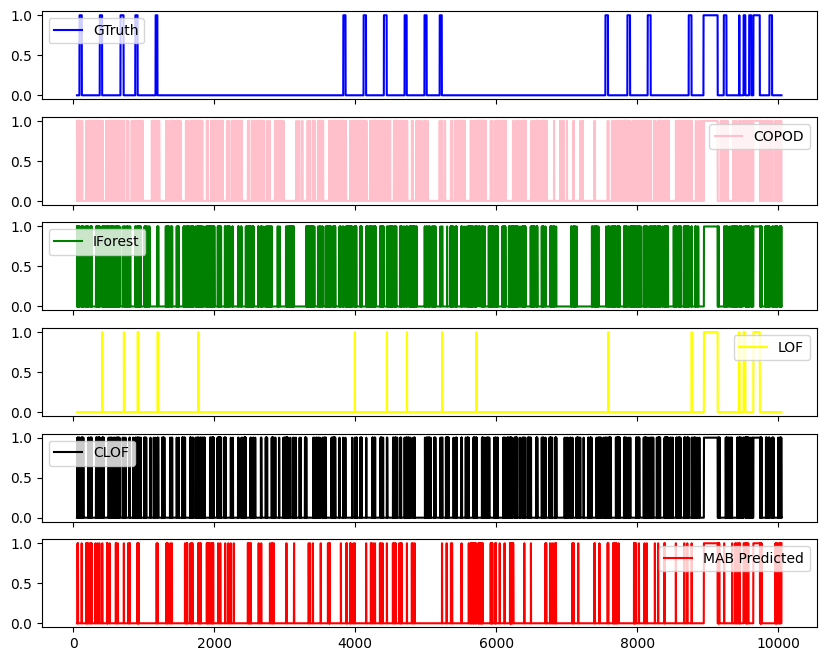

In [35]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, sharex=True, figsize=(10, 8))
index = range(50, 10050)

ax1.plot(index, sample_gtruth, color='blue', label='GTruth')
ax6.plot(index, score_np, color='red', label='MAB Predicted')
ax3.plot(index, score_list[0], color = 'green', label = 'IForest')
ax4.plot(index, score_list[1], color = 'yellow', label = 'LOF')
ax5.plot(index, score_list[2], color = 'black', label = 'CLOF')
ax2.plot(index, score_list[3], color = 'pink', label = 'COPOD')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')
ax5.legend(loc='upper left')
ax6.legend(loc='upper right')

plt.show()

In [ ]:
compare_df = pd.DataFrame({'Gtruth': sample_gtruth.values, 'Y_Pred': score_np})
compare_df['Equal'] = compare_df['Gtruth'] == compare_df['Y_Pred']
compare_df.to_csv(f'../temp.csv')